# Comparing expression of T KO & Eomes KO cells within celltypes

In [1]:
# Load Packages
suppressPackageStartupMessages({
    library(scran)
    library(ggplot2)
    library(data.table)
    library(stringr)
    library(purrr)
    library(BiocNeighbors)
    library(scater)
})

In [2]:
source('T/code/utils.R')
source('T/code/settings.R')

In [3]:
io$T = '/rds/project/rds-SDzz0CATGms/users/bt392/12_Eomes_T_Mixl1/T/'
io$Eomes = '/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/'

In [4]:
T_meta = fread(file.path(io$T, 'results/rna/mapping/sample_metadata_after_mapping.txt.gz')) %>% 
    .[!is.na(celltype.mapped_mnn)]
T_sce = load_SingleCellExperiment(file.path(io$T, 'processed/SingleCellExperiment.rds'), normalise=T, cells=T_meta$cell)
colData(T_sce) = T_meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [5]:
Eo_meta = fread(file.path(io$Eomes, 'results/rna/mapping/sample_metadata_after_mapping.txt.gz')) %>% 
    .[!is.na(celltype.mapped_mnn)]
Eo_sce = load_SingleCellExperiment(file.path(io$Eomes, 'processed/SingleCellExperiment.rds'), normalise=T, cells=Eo_meta$cell)
colData(Eo_sce) = Eo_meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [6]:
genes = intersect(rownames(T_sce), rownames(Eo_sce))
T_sce = T_sce[genes,]
Eo_sce = Eo_sce[genes, ]

In [7]:
summary(rownames(T_sce) == rownames(Eo_sce))

   Mode    TRUE 
logical   27869 

# Compare Differential expression per celltype

In [8]:
T_diff = fread(file.path(io$T, 'results/rna/differential/celltype_updated/pseudoBulkSpecific.txt.gz'))
Eomes_diff = fread(file.path(io$Eomes, 'results/rna/differential/celltype_updated/pseudoBulkSpecific.txt.gz'))

In [68]:
# Make dataframe with logFC and FDR for both T and Eo experiment per celltype
comparison = merge( T_diff %>% copy() %>% 
                      .[,c('logFC', 'padj_fdr', 'gene', 'variable')] %>%
                      setnames(c('logFC', 'padj_fdr'), c('T_logFC', 'T_padj_fdr')), 
                    Eomes_diff %>% copy() %>% 
                      .[,c('logFC', 'padj_fdr', 'gene', 'variable')] %>%
                      setnames(c('logFC', 'padj_fdr'), c('Eo_logFC', 'Eo_padj_fdr')),
                    by = c('gene', 'variable'), all = T)
comparison[is.na(T_logFC)]$T_logFC = 0
comparison[is.na(T_padj_fdr)]$T_padj_fdr = 1
comparison[is.na(Eo_logFC)]$Eo_logFC = 0
comparison[is.na(Eo_padj_fdr)]$Eo_padj_fdr = 1

comparison = comparison %>%
                .[,sig:=ifelse(T_padj_fdr <= 0.05 & Eo_padj_fdr <= 0.05 & abs(T_logFC) > 0.5 & abs(Eo_logFC) > 0.5, 'Both', 
                           ifelse(T_padj_fdr <= 0.05 & Eo_padj_fdr > 0.05 & abs(T_logFC) > 0.5, 'T',
                                ifelse(T_padj_fdr > 0.05 & Eo_padj_fdr <= 0.05 & abs(Eo_logFC) > 0.5, 'Eo', 'Not-sig')))] #%>% 
           # .[sig!='Not-sig'] # %>%
            #.[,sig:=ifelse(abs(T_logFC) <= 0.5 & abs(Eo_logFC) <= 0.5, 'Non-sig', sig)]

In [73]:
# remove clear batch genes
batch_genes = c('Xist', 'Cdkn1c', 'Cdkn1a', 'Phlda2', 'H13')
comparison = comparison[!gene %in% batch_genes]

# Rename long celltypes
celltypes_rename = c('Forebrain Midbrain Hindbrain' = 'Fore/Mid/Hindbrain',
                     'Intermediate mesoderm' = 'Intermediate m.',
                     'Lateral plate mesoderm' = 'Lateral plate m.',
                     'Allantois endothelium' = 'Allantois endoth.')

# Cap expression for display purposes
comparison = comparison %>%
    .[, `:=`(T_logFC = ifelse(T_logFC>3, 3, 
                              ifelse(T_logFC <=-3, -3, T_logFC)),
             Eo_logFC = ifelse(Eo_logFC>3.5, 3.5, 
                              ifelse(Eo_logFC <=-3.5, -3.5, Eo_logFC)))] %>% 
    .[, variable := gsub('_', ' ', variable)] %>%
    .[, variable := str_replace_all(variable, celltypes_rename)] %>% 
    .[variable %in% c('Allantois','Allantois endoth.','Lateral plate m.','NMP')]

In [74]:
top = 7
labels = rbind(comparison %>% copy() %>% .[sig!='Not-sig'] %>% 
            .[order(-abs(Eo_logFC))] %>% 
            .[, head(.SD, top), by='variable'],
        comparison %>% copy() %>% .[sig!='Not-sig'] %>% 
            .[order(-abs(T_logFC))] %>% 
            .[, head(.SD, top), by='variable']
    ) %>% unique(by=c('variable', 'gene')) %>% .[sig!='Non-sig']

labels = rbind(comparison %>% copy() %>% .[sig=='Both'] %>% 
            .[order(-abs(Eo_logFC))] %>% 
            .[, head(.SD, top), by='variable'],
        comparison %>% copy() %>% .[sig!='Not-sig'] %>% 
            .[order(-abs(T_logFC))] %>% 
            .[, head(.SD, top), by='variable']
    ) %>% unique(by=c('variable', 'gene')) %>% .[sig=='Both']

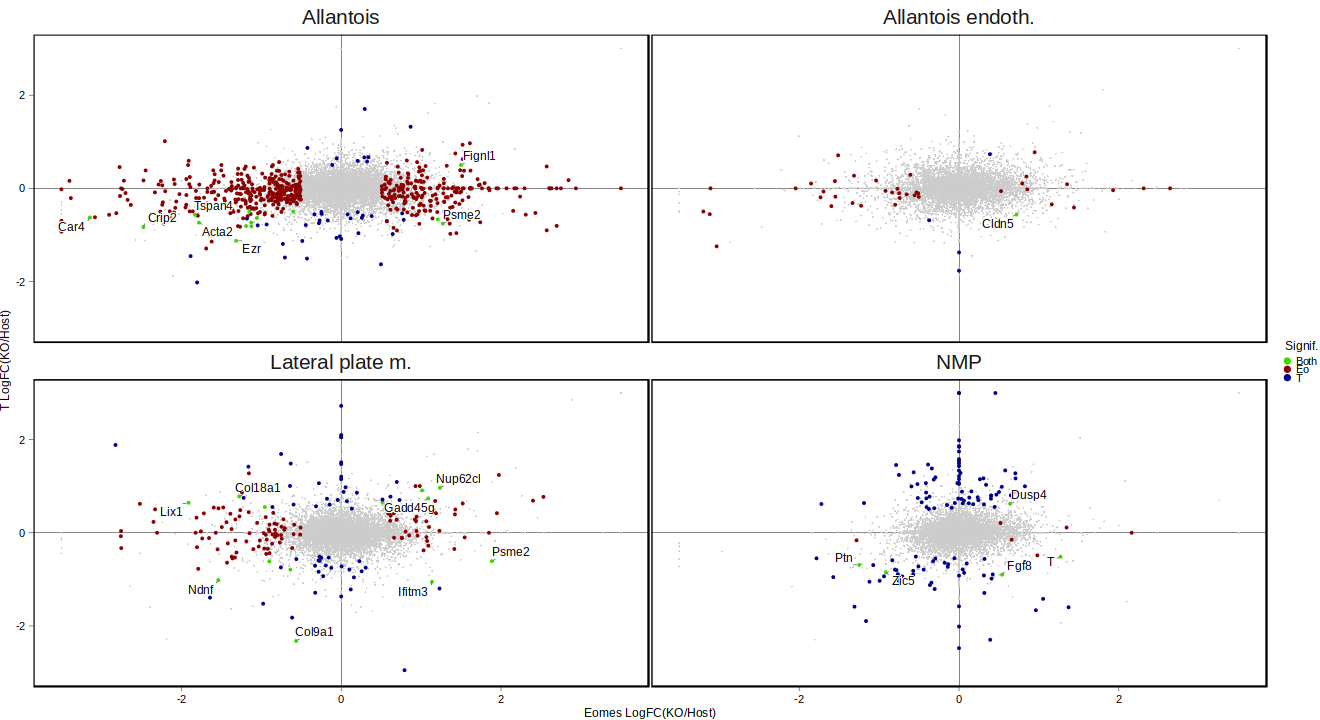

In [80]:
options(repr.plot.width=11, repr.plot.height=6)

p = ggplot(comparison[sig!='Not-sig'], aes(Eo_logFC, T_logFC, color = sig, label=gene)) + 
    geom_hline(yintercept=0, linewidth = 0.1) + geom_vline(xintercept=0, linewidth = 0.1) +
    ggrastr::rasterise(geom_point(data = comparison[sig=='Not-sig'], size=-0.3, color='grey80'), dpi = 600) + 
    geom_point(size = 0.05) + 
    ggrepel::geom_text_repel(data = labels, color = 'black',
                            max.overlaps = 10,
                            bg.color='white', 
                            size = 7 * 0.35, 
                            bg.r = 0.1,
                             force = 1,
                            box.padding = 0.15,
                            min.segment.length = 0,
                            segment.size = 0.1,
                            seed = 1) +
    guides(color = guide_legend(override.aes = list(size = 1), title = 'Signif.')) +
    facet_wrap(~variable, ncol = 2, scales='fixed') + 
    xlim(-3.5,3.5) + ylim(-3,3) + 
    xlab('Eomes LogFC(KO/Host)') + 
    ylab('T LogFC(KO/Host)') + 
    scale_color_manual(values = c('T' = 'darkblue', 'Eo' = 'darkred', 'Both' = '#3dd600')) + 
    theme_bw() + 
    # theme(axis.text = element_text(size=12, color='black'),
    #       axis.title = element_text(size=14, color='black'),
    #       panel.border = element_rect(color='black', linewidth=1),
    #       legend.position='right',
    #       strip.background=element_blank(),
    #       strip.text = element_text(size=14, color='black'),
    #       legend.text = element_text(size=12),
    #       legend.title = element_text(size=14))
    theme(
          axis.text = element_text(size = 6, color = 'black'),
          axis.ticks=element_line(linewidth=0.1, color = 'black'),
          axis.title.x = element_text(size=7, color='black'),
          axis.title.y = element_text(size=7, color='black'),
          legend.text = element_text(size=6, color='black'),
          legend.title = element_text(size=7, color='black'),
          plot.title = element_text(size=8, color='black', hjust = 0.5, vjust = -1),
          panel.border = element_rect(color='black', linewidth=0.5),
          panel.spacing = unit(0.5, "mm"),
          legend.position = 'right', # Position legend outside the plot (right and center vertically)
          legend.justification = c("left", "center"), # Justify legend to the center vertically and to the left horizontally
          legend.box.margin = margin(0, 0, 0, 0), # Adjust the margins around the legend box
          legend.margin = margin(0, 0, 0, 0), # Adjust the margins inside the legend box
          legend.key = element_blank(), 
          legend.key.size  = unit(1, "mm"),
          plot.margin = margin(0,0,0,0),
          panel.grid = element_blank(), 
          strip.background=element_blank(),
          strip.text.x = element_text(size = 12))

p



In [81]:
ggsave(file.path(io$T, 'figures/T_Eomes_DEG_comparison.pdf'), 
       plot = p, 
       width = 80, height = 86, units = "mm")

# Expression on atlas

In [8]:
io$atlas_sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/SingleCellExperiment.rds'
io$atlas_metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'

In [9]:
# Load cell metadata
meta_atlas <- fread(io$atlas_metadata)

# Load SingleCellExperiment
sce_atlas <- load_SingleCellExperiment(io$atlas_sce, normalise = TRUE, cells = meta_atlas$cell)

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(sce_atlas)] %>%
  .[!duplicated(symbol)]

rownames(sce_atlas) = gene_metadata[match(rownames(sce_atlas), ens_id), symbol]

In [10]:
meta_atlas = meta_atlas %>% 
    .[, `:=`(
        'Eomes' = as.vector(logcounts(sce_atlas['Eomes', cell])),
        'T' = as.vector(logcounts(sce_atlas['T', cell]))
            )]

In [11]:
head(meta_atlas)

cell,barcode,sample,stage,sequencing.batch,doublet,stripped,celltype,umapX,umapY,nFeature_RNA,nCount_RNA,index,celltype_extended,Eomes,T
<chr>,<chr>,<int>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>
cell_1,AAAGGCCTCCACAA,1,E6.5,1,FALSE,FALSE,Epiblast,-10.227546,-2.8816875,2547,8963,1,Epiblast,0.000000,0.0000000
cell_2,AACAAACTCGCCTT,1,E6.5,1,FALSE,FALSE,Primitive_Streak,-6.625458,0.1089605,3725,19573,2,Primitive_Streak,2.763019,0.8693811
cell_5,AACAGAGAATCAGC,1,E6.5,1,FALSE,FALSE,ExE_ectoderm,10.061009,-0.0293132,3480,14193,5,ExE_ectoderm,1.671832,0.0000000
cell_6,AACATATGAATCGC,1,E6.5,1,FALSE,FALSE,Epiblast,-10.454418,-0.2694517,3866,20347,6,Epiblast,1.372325,0.0000000
cell_8,AACCGATGGCTTCC,1,E6.5,1,FALSE,FALSE,Epiblast,-11.047206,-2.2052687,4044,22549,8,Epiblast,0.000000,0.0000000
cell_9,AACGTGTGCTCTAT,1,E6.5,1,FALSE,FALSE,Epiblast,-11.111009,-2.7534415,4356,24509,9,Epiblast,0.000000,0.0000000


In [12]:
p_Eomes = ggplot(meta_atlas[order(Eomes)], aes(umapX, umapY, color=Eomes)) +
    ggrastr::rasterise(geom_point(size=0.1, color = 'black'), dpi = 600) + 
    ggrastr::rasterise(geom_point(size=-0.1), dpi = 900) + 
    scale_color_gradientn(colors = c('grey95', 'blue', 'red')) + 
    guides(color = guide_colourbar(
         barwidth = 2.5, barheight = 0.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    coord_fixed(ratio = 0.75) + 
    ggtitle('Eomes')

p_T = ggplot(meta_atlas[order(T)], aes(umapX, umapY, color=T)) +
    ggrastr::rasterise(geom_point(size=0.1, color = 'black'), dpi = 600) + 
    ggrastr::rasterise(geom_point(size=-0.1), dpi = 900) + 
    scale_color_gradientn(colors = c('grey95', 'blue', 'red')) + 
    guides(color = guide_colourbar(
         barwidth = 2.5, barheight = 0.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    coord_fixed(ratio = 0.75) + 
    ggtitle('T')

theme = theme_void() + 
        theme(
          legend.position = 'bottom',
          legend.title = element_blank(),
          legend.text = element_text(size = 6, vjust = 3),
          strip.background=element_blank(),
          plot.title = element_text(size = 8, hjust = 0.5),
          plot.margin = margin(1,1,1,1)
        )

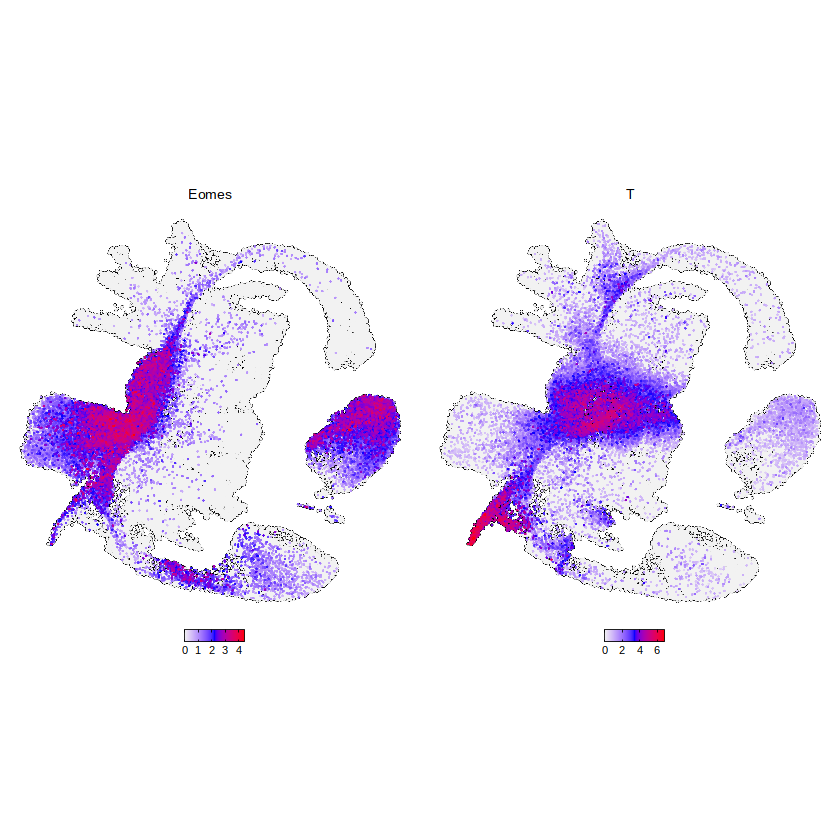

In [13]:
ggarrange(p_Eomes + theme, p_T + theme)

In [140]:
ggsave(file.path(io$T, 'figures/T_Eomes_atlas_expression.pdf'), 
       plot = ggarrange(p_Eomes + theme, p_T + theme), 
       width = 67, height = 50, units = "mm")

In [11]:
### Violins instead of UMAP
# Use updated cell type annotations where relevant
original_keep = c('Allantois', 
                  paste0('Blood_progenitors_', 1:2),
                  'Cardiomyocytes',
                  'Caudal_epiblast',
                  'Caudal_Mesoderm',
                  'Caudal_neurectoderm',
                  'Def._endoderm',
                  'Epiblast',
                  'ExE_ectoderm',
                  'ExE_endoderm',
                  'Forebrain_Midbrain_Hindbrain',
                  'Gut',
                  'Nascent_mesoderm',
                  'Neural_crest',
                  'NMP',
                  'Notochord', 
                  'Parietal_endoderm',
                  'PGC',
                  'Pharyngeal_mesoderm',
                  'Rostral_neurectoderm', 
                  'Spinal_cord',
                  'Surface_ectoderm', # Except for amniotic ectoderm
                  'Visceral_endoderm'                  
                )
original_replace = c('Endothelium',
                    paste0('Erythroid', 1:3), # --> Erythroid
                    'ExE_mesoderm', # --> Replace with LPM all together
                     'Haematoendothelial_progenitors',# --> Use exteended atlas label
                   'Mixed_mesoderm' # Use the new labels as they are more precise
                )

meta_atlas = meta_atlas[,celltype_updated := celltype] %>% 
    # Add higher resolution endothelium annotation
    .[,celltype_updated := ifelse(celltype_updated %in% c('Endothelium', 'Haematoendothelial_progenitors'), celltype_extended, celltype_updated), ] %>% 
    # Merge Erythroids 
    .[,celltype_updated := ifelse(celltype_updated %in% paste0('Erythroid', 1:3), 'Erythroid', celltype_updated)] %>%
    # Change 'ExE mesoderm' to 'Lateral plate mesoderm'
    .[,celltype_updated := ifelse(celltype_updated == 'ExE_mesoderm', 'Lateral_plate_mesoderm', celltype_updated)] %>% 
    # Improve mixed mesoderm annotation
    .[,celltype_updated := ifelse(celltype_updated == 'Mixed_mesoderm', celltype_extended, celltype_updated)] %>% 
    # Add amniotic ectoderm    
    .[,celltype_updated := ifelse(celltype_extended == 'Amniotic_ectoderm', 'Amniotic_ectoderm', celltype_updated)] %>%
    # Add YS mesothelium
    .[,celltype_updated := ifelse(celltype_extended == 'YS_mesothelium', 'YS_mesothelium', celltype_updated)]

celltypes_keep = meta_atlas %>% .[, N := .N, by = 'celltype_updated'] %>% .[N > 50] %>% .$celltype_updated %>% unique()
meta_atlas2 = meta_atlas %>% .[celltype_updated %in% celltypes_keep]

celltype2germlayer = c(
    'Amniotic_ectoderm' = 'ectoderm', 
    'Surface_ectoderm' = 'ectoderm', 
    'Caudal_neurectoderm' = 'ectoderm',
    'Rostral_neurectoderm' = 'ectoderm', 
    'Spinal_cord' = 'ectoderm', 
    'NMP' = 'ectoderm', 
    'Forebrain_Midbrain_Hindbrain' = 'ectoderm', 
    'Neural_crest' = 'ectoderm', 

    'Notochord' = 'endoderm', 
    'Def._endoderm' = 'endoderm', 
    'Gut' = 'endoderm', 

    'PGC' = 'other', 

    'Intermediate_mesoderm' = 'mesoderm', 
    'Nascent_mesoderm' = 'mesoderm',
    'Lateral_plate_mesoderm' = 'mesoderm', 
    'Allantois' = 'mesoderm', 
    'Somitic_mesoderm' = 'mesoderm', 
    'Caudal_Mesoderm' = 'mesoderm', 
    'Mesenchyme' = 'mesoderm', 
    'Pharyngeal_mesoderm' = 'mesoderm', 
    'Paraxial_mesoderm' = 'mesoderm', 
    'Cardiomyocytes' = 'mesoderm', 
    'YS_mesothelium' = 'mesoderm', 
    'Venous_endothelium' = 'mesoderm', 
    'Embryo_proper_endothelium' = 'mesoderm', 
    'Allantois_endothelium' = 'mesoderm', 
    'YS_endothelium' = 'mesoderm', 
    'Haematoendothelial_progenitors' = 'mesoderm',
    'Blood_progenitors_1' = 'mesoderm', 
    'Blood_progenitors_2' = 'mesoderm',
    'Erythroid' = 'mesoderm',
    'EMP' = 'mesoderm',
    'Endocardium' = 'mesoderm',
    
    'Epiblast' = 'Early',
    'Caudal_epiblast' = 'Early', 
    'Primitive_Streak' = 'Early',
    'Anterior_Primitive_Streak' = 'Early',
    
    'ExE_ectoderm' = 'non-epiblast derived',
    'Visceral_endoderm' = 'non-epiblast derived',
    'ExE_endoderm' = 'non-epiblast derived',
    'Parietal_endoderm' = 'non-epiblast derived',
    
    'Other' = ''

)

meta_atlas2 = meta_atlas2[,germ_layer := factor(
        str_to_title(
            celltype2germlayer[celltype_updated]), 
    levels = c('Early', 'Mesoderm', 'Endoderm', 'Ectoderm','Other', 'Non-Epiblast Derived'))] %>% 
    .[, celltype_updated := factor(gsub('_', ' ', celltype_updated), levels = gsub('_', ' ', names(celltype2germlayer)))] #%>% 


In [12]:
meta_atlas3 = meta_atlas2 %>% copy() %>%
    .[,.(celltype_updated, germ_layer, T, Eomes)] %>% 
    melt(id.vars = c('celltype_updated', 'germ_layer'))
head(meta_atlas3)

celltype_updated,germ_layer,variable,value
<fct>,<fct>,<fct>,<dbl>
Epiblast,Early,T,0.0000000
Primitive Streak,Early,T,0.8693811
ExE ectoderm,Non-Epiblast Derived,T,0.0000000
Epiblast,Early,T,0.0000000
Epiblast,Early,T,0.0000000
Epiblast,Early,T,0.0000000


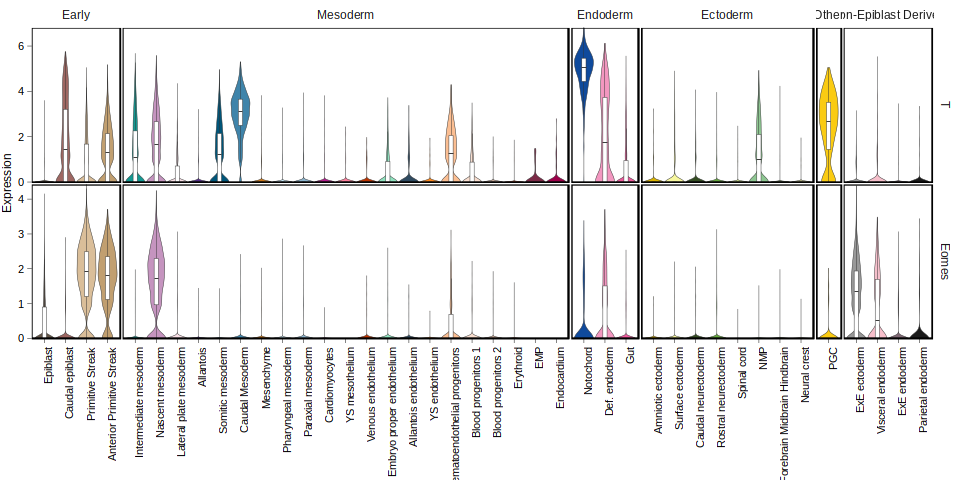

In [13]:
colors = c(opts$celltype.colors, opts$celltype_extended.colors)
names(colors) = gsub('_', ' ', names(colors))

options(repr.plot.width=8, repr.plot.height=4)
p = ggplot(meta_atlas3, aes(celltype_updated, value, fill = celltype_updated)) + 
    geom_violin(scale = 'width', linewidth = 0.1) + 
    geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA, linewidth = 0.1) + 
    scale_fill_manual(values = colors) + 
    scale_y_continuous(expand = c(0,0)) +
    ylab('Expression') + 
    facet_grid(variable~germ_layer, scales = 'free', space = 'free_x') + 
    theme_bw() + 
    theme(
        axis.title = element_text(size = 7),
        strip.text = element_text(size = 7),
        axis.text = element_text(color = 'black', size = 6),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 1),
        axis.title.x = element_blank(),
        panel.grid = element_blank(),
        strip.background = element_blank(),
        legend.position = 'none',
        plot.margin = margin(1,1,1,1),
        panel.border = element_rect(color='black', linewidth=0.5),
        panel.spacing = unit(0.5, "mm"),
        axis.ticks=element_line(linewidth=0.1, color = 'black')
    )

p

In [14]:
ggsave(file.path(io$basedir, 'figures/atlas_expression_violins.pdf'), 
       plot = p, 
       width = 85, height = 60, units = "mm")

In [34]:
tmp = meta_atlas2 %>% copy() %>%
    .[, ':='(mean_T = mean(T),
             mean_Eo = mean(Eomes)),
      by = 'celltype_updated'] %>%
    .[mean_T > 0.5 | mean_Eo > 0.5] %>% 
    .$celltype_updated %>% unique()

In [39]:
unique(meta_atlas2$celltype_updated)

[1] Epiblast                       Primitive Streak              
 [3] ExE ectoderm                   Visceral endoderm             
 [5] ExE endoderm                   Nascent mesoderm              
 [7] Rostral neurectoderm           Blood progenitors 2           
 [9] Paraxial mesoderm              Lateral plate mesoderm        
[11] Intermediate mesoderm          Pharyngeal mesoderm           
[13] Caudal epiblast                PGC                           
[15] Mesenchyme                     Haematoendothelial progenitors
[17] Blood progenitors 1            Surface ectoderm              
[19] Gut                            Caudal neurectoderm           
[21] Allantois endothelium          Notochord                     
[23] Somitic mesoderm               Caudal Mesoderm               
[25] Erythroid                      Embryo proper endothelium     
[27] Amniotic ectoderm              Def. endoderm                 
[29] Parietal endoderm              Allantois                     
[31] Anterior Primitive Streak      Venous endothelium            
[33] Forebrain Midbrain Hindbrain   Spinal cord                   
[35] Cardiomyocytes                 EMP                           
[37] NMP                            YS mesothelium                
[39] YS endothelium                 Endocardium                   
[41] Neural crest                  
42 Levels: Amniotic ectoderm Surface ectoderm ... Other

In [43]:
as.character(tmp)

[1] "Primitive Streak"               "ExE ectoderm"                  
 [3] "Visceral endoderm"              "Nascent mesoderm"              
 [5] "Intermediate mesoderm"          "Caudal epiblast"               
 [7] "PGC"                            "Haematoendothelial progenitors"
 [9] "Gut"                            "Notochord"                     
[11] "Somitic mesoderm"               "Caudal Mesoderm"               
[13] "Def. endoderm"                  "Anterior Primitive Streak"     
[15] "NMP"

In [44]:
meta_atlas3 = meta_atlas2 %>% copy() %>%
    .[, celltype_updated := as.character(celltype_updated)] %>% 
    .[, celltype_updated2 := ifelse(celltype_updated %in% c(as.character(tmp), 'Epiblast'), celltype_updated, 'Other')] %>%
    .[,.(celltype_updated2, germ_layer, T, Eomes)] %>% 
    melt(id.vars = c('celltype_updated2', 'germ_layer')) %>%
    .[, celltype_updated2 := factor(celltype_updated2, levels = gsub('_', ' ', names(celltype2germlayer)))]
head(meta_atlas3)

celltype_updated2,germ_layer,variable,value
<fct>,<fct>,<fct>,<dbl>
Epiblast,Early,T,0.0000000
Primitive Streak,Early,T,0.8693811
ExE ectoderm,Non-Epiblast Derived,T,0.0000000
Epiblast,Early,T,0.0000000
Epiblast,Early,T,0.0000000
Epiblast,Early,T,0.0000000


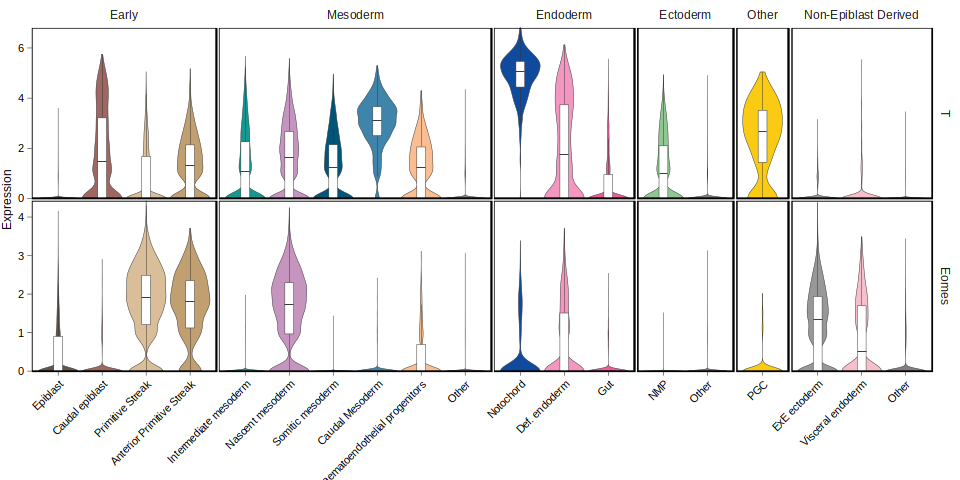

In [47]:
colors = c(opts$celltype.colors, opts$celltype_extended.colors)
names(colors) = gsub('_', ' ', names(colors))

options(repr.plot.width=8, repr.plot.height=4)
p = ggplot(meta_atlas3, aes(celltype_updated2, value, fill = celltype_updated2)) + 
    geom_violin(scale = 'width', linewidth = 0.1) + 
    geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA, linewidth = 0.1) + 
    scale_fill_manual(values = colors) + 
    scale_y_continuous(expand = c(0,0)) +
    ylab('Expression') + 
    facet_grid(variable~germ_layer, scales = 'free', space = 'free_x') + 
    theme_bw() + 
    theme(
        axis.title = element_text(size = 7),
        strip.text = element_text(size = 7),
        axis.text = element_text(color = 'black', size = 6),
        axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
        axis.title.x = element_blank(),
        panel.grid = element_blank(),
        strip.background = element_blank(),
        legend.position = 'none',
        plot.margin = margin(1,1,1,1),
        panel.border = element_rect(color='black', linewidth=0.5),
        panel.spacing = unit(0.5, "mm"),
        axis.ticks=element_line(linewidth=0.1, color = 'black')
    )

p

In [50]:
ggsave(file.path(io$basedir, 'figures/atlas_expression_violins_trimmed.pdf'), 
       plot = p, 
       width = 78, height = 55, units = "mm")

In [ ]:
head(meta_atlas)

#### Not specific but any sig from 0.5

In [4]:
T_diff = fread(file.path(io$T, 'results/rna/differential/manual/pseudoBulkAll.txt.gz'))
Eomes_diff = fread(file.path(io$Eomes, 'results/rna/differential/celltype_updated/pseudoBulkAll.txt.gz'))

In [5]:
# Make dataframe with logFC and FDR for both T and Eo experiment per celltype
comparison = merge( T_diff %>% copy() %>% 
                      .[,c('logFC', 'padj_fdr', 'gene', 'variable')] %>%
                      setnames(c('logFC', 'padj_fdr'), c('T_logFC', 'T_padj_fdr')), 
                    Eomes_diff %>% copy() %>% 
                      .[,c('logFC', 'padj_fdr', 'gene', 'variable')] %>%
                      setnames(c('logFC', 'padj_fdr'), c('Eo_logFC', 'Eo_padj_fdr')),
                    by = c('gene', 'variable')) %>% 
            .[,sig:=ifelse(T_padj_fdr <= 0.05 & Eo_padj_fdr <= 0.05 & abs(T_logFC) > 0.5 & abs(Eo_logFC) > 0.5, 'Both', 
                           ifelse(T_padj_fdr <= 0.05 & Eo_padj_fdr > 0.05 & abs(T_logFC) > 0.5, 'T',
                                ifelse(T_padj_fdr > 0.05 & Eo_padj_fdr <= 0.05 & abs(Eo_logFC) > 0.5, 'Eo', 'Not-sig')))] #%>% 
           # .[sig!='Not-sig'] # %>%
            #.[,sig:=ifelse(abs(T_logFC) <= 0.5 & abs(Eo_logFC) <= 0.5, 'Non-sig', sig)]

In [6]:
# remove clear batch genes
batch_genes = c('Xist', 'Cdkn1c', 'Cdkn1a', 'Phlda2', 'H13')
comparison = comparison[!gene %in% batch_genes]

# Cap expression for display purposes
comparison = comparison %>%
    .[, `:=`(T_logFC = ifelse(T_logFC>3, 3, 
                              ifelse(T_logFC <=-3, -3, T_logFC)),
             Eo_logFC = ifelse(Eo_logFC>3.5, 3.5, 
                              ifelse(Eo_logFC <=-3.5, -3.5, Eo_logFC)))]

In [7]:
labels = rbind(comparison %>% copy() %>% .[sig!='Not-sig'] %>% 
            .[order(-abs(Eo_logFC))] %>% 
            .[, head(.SD, 20), by='variable'],
        comparison %>% copy() %>% .[sig!='Not-sig'] %>% 
            .[order(-abs(T_logFC))] %>% 
            .[, head(.SD, 20), by='variable']
    ) %>% unique(by=c('variable', 'gene')) %>% .[sig!='Non-sig']

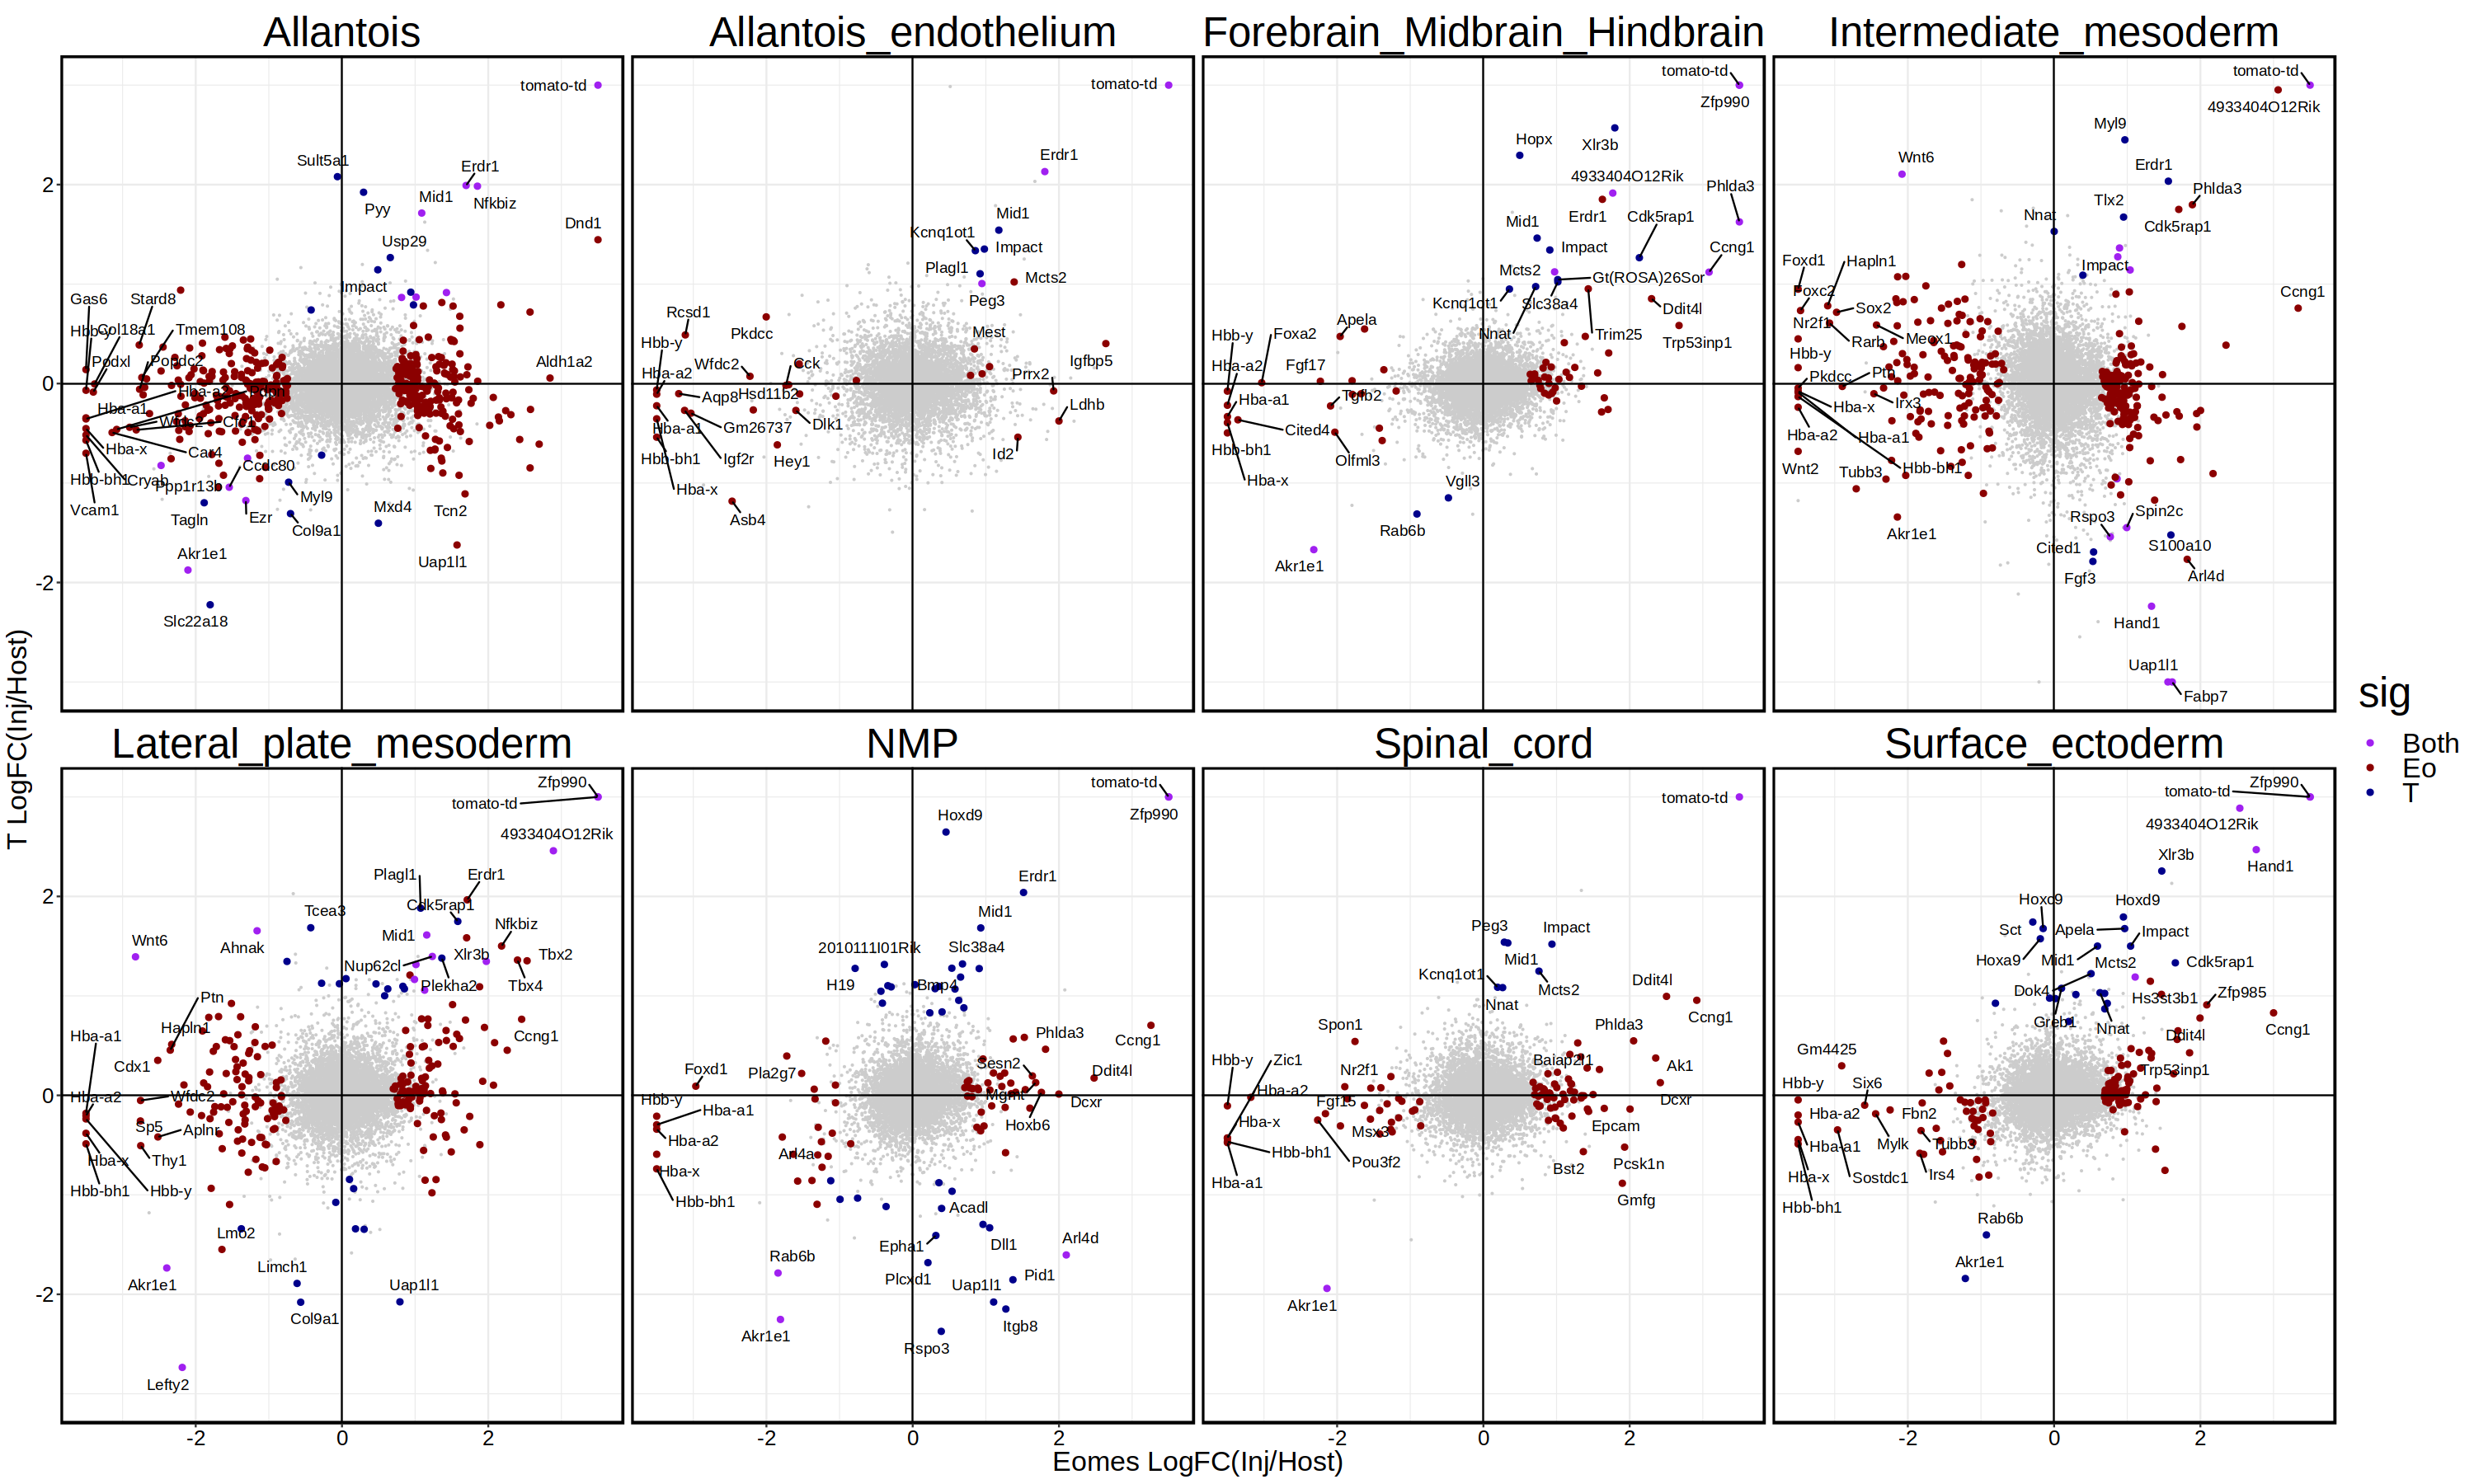

In [8]:
options(repr.plot.width=25, repr.plot.height=15)

ggplot(comparison[sig!='Not-sig'], aes(Eo_logFC, T_logFC, color = sig, label=gene)) + 
    geom_point(data = comparison[sig=='Not-sig'], size=0.1, color='grey80') + 
    geom_point() + 
    ggrepel::geom_text_repel(data = labels, color = 'black',
                            max.overlaps = Inf,
                            box.padding = 0.5) +
    geom_hline(yintercept=0) + geom_vline(xintercept=0) +
    facet_wrap(~variable, ncol = 4, scales='fixed') + 
    xlim(-3.5,3.5) + ylim(-3,3) + 
    xlab('Eomes LogFC(Inj/Host)') + 
    ylab('T LogFC(Inj/Host)') + 
    scale_color_manual(values = c('T' = 'darkblue', 'Eo' = 'darkred', 'Both' = 'purple')) + 
    theme_bw() + 
    theme(axis.text = element_text(size=15, color='black'),
          axis.title = element_text(size=20, color='black'),
          panel.border = element_rect(color='black', linewidth=1.3),
          legend.position='right',
          strip.background=element_blank(),
          strip.text = element_text(size=30, color='black'),
          legend.text = element_text(size=20),
          legend.title = element_text(size=30))